# Ελαχιστοποίηση του Makespan σε ένα Job-Shop με το PROC OPTMODEL

## Σύνοψη για Στελέχη

Μια μικρή μονάδα διακριτής παραγωγής πρέπει να περάσει τέσσερα εξαρτήματα — ένα **Βραχίονας**, ένα **Φλάντζα**, ένα **Περίβλημα** και έναν **Άξονας** — μέσα από μια σταθερή ακολουθία τριών εργασιών κατεργασίας η καθεμία, μοιραζόμενα τέσσερις μηχανές μοναδιαίας δυναμικότητας (**Πριόνι**, **Φρέζα**, **Δράπανο**, **Τροχός**). Καμία μηχανή δεν μπορεί να εκτελεί δύο εργασίες ταυτόχρονα, και οι εργασίες κάθε εξαρτήματος πρέπει να ακολουθούν την τεχνολογική τους σειρά. Διατυπώνουμε το χρονοδιάγραμμα ελαχιστοποίησης του makespan ως ένα μεικτό ακέραιο πρόγραμμα στο **PROC OPTMODEL** — μεταβλητές χρόνου έναρξης, περιορισμούς προτεραιότητας τέλους-προς-έναρξη, και διαζευκτικούς (big-*M*) περιορισμούς μη επικάλυψης μεταξύ κάθε ζεύγους εργασιών που μοιράζονται μια μηχανή — και το επιλύουμε σε αποδεδειγμένη βελτιστότητα.

Ο επιλυτής MILP επιστρέφει ένα **βέλτιστο makespan 120 λεπτών** (`Solution Status = Optimal`, `Objective Value = 120`). Το προκύπτον χρονοδιάγραμμα συμπυκνώνει και τις δώδεκα εργασίες ώστε κάθε μηχανή να επεξεργάζεται το πολύ ένα εξάρτημα κάθε φορά και κάθε εξάρτημα να κατεργάζεται Πριόνι/Φρέζα/Δράπανο πριν τον Τροχό στην απαιτούμενη σειρά του. Δύο εργασίες τελειώνουν ακριβώς στο λεπτό 120 — το τρόχισμα του Βραχίονα και το φρεζάρισμα του Περιβλήματος — οπότε τόσο η μηχανή Τροχός όσο και η Φρέζα βρίσκονται στην κρίσιμη διαδρομή που καθορίζει το μήκος του χρονοδιαγράμματος.

## Πηγές Δεδομένων

Όλα τα δεδομένα ορίζονται εντός του σημειωματαρίου — καμία εξωτερική πηγή ή δίκτυο.

| Σύνολο δεδομένων | Γραμμές | Βασικές Μεταβλητές | Περιγραφή |
|---------|------|---------------|-------------|
| `jobshop` | 12 | `op`, `job`, `opnum`, `machine`, `dur`, `jobname`, `mname` | Μία γραμμή ανά εργασία (4 εξαρτήματα × 3 εργασίες). Η `machine` (1–4) είναι η μηχανή που χρειάζεται η εργασία· η `dur` είναι ο χρόνος επεξεργασίας της σε λεπτά· οι `jobname`/`mname` είναι αναγνώσιμες ετικέτες εξαρτήματος και μηχανής. |
| `sched` | 12 | `op`, `start`, `finish` | Έξοδος OPTMODEL: το βέλτιστο λεπτό έναρξης και λήξης κάθε εργασίας. |
| `schedule` | 12 | `jobname`, `opnum`, `mname`, `dur`, `start`, `finish` | Το `jobshop` συγχωνευμένο με τους επιλυμένους χρόνους, ταξινομημένο κατά μηχανή και μετά έναρξη — το αναγνώσιμο από άνθρωπο χρονοδιάγραμμα. |
| `mk` | 1 | `makespan` | Το πραγματοποιημένο makespan (χρόνος τελευταίας λήξης). |

## Το πρόβλημα χρονοπρογραμματισμού

Σε ένα **job shop**, αρκετά εξαρτήματα ("εργασίες") περνούν το καθένα μέσα από μια σταθερή ακολουθία εργασιών, και κάθε εργασία εκτελείται σε μια συγκεκριμένη μηχανή. Δύο εργασίες δεν μπορούν να καταλαμβάνουν την ίδια μηχανή την ίδια στιγμή (οι μηχανές είναι *μοναδιαίοι* πόροι), και εντός ενός εξαρτήματος οι εργασίες πρέπει να τηρούν την τεχνολογική τους σειρά. Ο σχεδιαστής θέλει χρόνους έναρξης για κάθε εργασία που τηρούν και τους δύο κανόνες, διατηρώντας παράλληλα το συνολικό μήκος του χρονοδιαγράμματος — το **makespan** — όσο το δυνατόν μικρότερο.

Αυτό είναι ένα κλασικό πρόβλημα διαζευκτικού χρονοπρογραμματισμού. Το μοντελοποιούμε ως μεικτό ακέραιο πρόγραμμα:

- έναν συνεχή-αλλά-ακέραιο **χρόνο έναρξης** `s[o]` για κάθε εργασία, και μια μεταβλητή makespan `Cmax`·
- **προτεραιότητα**: η εργασία *k+1* ενός εξαρτήματος ξεκινά όχι νωρίτερα από ό,τι τελειώνει η εργασία *k*·
- **διαζευκτική δυναμικότητα μηχανής**: για κάθε ζεύγος εργασιών που μοιράζονται μια μηχανή, μια δυαδική `y` αποφασίζει ποια προηγείται, και ένας όρος big-*M* απενεργοποιεί την ανενεργή διάταξη — ώστε οι δύο εργασίες να μην μπορούν ποτέ να επικαλυφθούν·
- **στόχος**: ελαχιστοποίηση του `Cmax`, το οποίο εξαναγκάζεται να είναι τουλάχιστον ίσο με τον χρόνο λήξης κάθε εργασίας.

Το PROC OPTMODEL είναι η διαδικασία αλγεβρικής μοντελοποίησης του SAS/OR· ο επιλυτής MILP του βρίσκει το *αποδεδειγμένα βέλτιστο* συντομότερο χρονοδιάγραμμα.

> **Μια σημείωση για το PROC CLP.** Το SAS προσφέρει επίσης το PROC CLP, μια > μηχανή προγραμματισμού λογικής περιορισμών με ειδική σύνταξη χρονοπρογραμματισμού (δραστηριότητες, > πόροι, προτεραιότητα). Η διατύπωση MILP του OPTMODEL εδώ επιλύει το > ταυτόσημο πρόβλημα και επιστρέφει ένα πιστοποιητικό βελτιστότητας, κάτι που η αναζήτηση > εφικτότητας του CLP δεν κάνει.

## Βήμα 1 — Ορισμός της περίπτωσης του shop

Τέσσερα εξαρτήματα, τρεις εργασίες το καθένα, σε τέσσερις μηχανές. Κάθε γραμμή καθορίζει τη μηχανή που χρειάζεται μια εργασία και τον χρόνο επεξεργασίας της σε λεπτά. Οι εργασίες ενός εξαρτήματος παρατίθενται με τεχνολογική σειρά (`opnum` 1, 2, 3).

In [1]:
ΔΕΔΟΜΕΝΑ jobshop;
    LENGTH jobname $24 mname $20;
    ΕΙΣΟΔΟΣ op job opnum machine dur jobname $ mname $;
    DATALINES;
1  1 1 1 25 Βραχίονας  Πριόνι
2  1 2 3 40 Βραχίονας  Δράπανο
3  1 3 4 20 Βραχίονας  Τροχός
4  2 1 2 35 Φλάντζα  Φρέζα
5  2 2 3 25 Φλάντζα  Δράπανο
6  2 3 1 15 Φλάντζα  Πριόνι
7  3 1 3 30 Περίβλημα  Δράπανο
8  3 2 1 20 Περίβλημα  Πριόνι
9  3 3 2 45 Περίβλημα  Φρέζα
10 4 1 1 20 Άξονας  Πριόνι
11 4 2 2 30 Άξονας  Φρέζα
12 4 3 4 25 Άξονας  Τροχός
;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=jobshop noobs label;
    TITLE "Περίπτωση Job-Shop: 4 εξαρτήματα, 3 εργασίες το καθένα, 4 μηχανές";
    ΜΕΤΑΒΛΗΤΗ op jobname opnum mname dur;
    ΕΤΙΚΕΤΑ op="Λειτ." jobname="Εξάρτημα" opnum="Αρ. Εργ." mname="Μηχανή" dur="Διάρκεια (λεπτά)";
ΕΚΤΕΛΕΣΗ;

                           Περίπτωση Job-Shop: 4 εξαρτήματα, 3 εργασίες το καθένα, 4 μηχανές                            

    Λειτ.            Εξάρτημα       Αρ. Εργ.          Μηχανή               Διάρκεια (λεπτά)
        1  Βραχίονας                       1  Πριόνι                                     25
        2  Βραχίονας                       2  Δράπανο                                    40
        3  Βραχίονας                       3  Τροχός                                     20
        4  Φλάντζα                         1  Φρέζα                                      35
        5  Φλάντζα                         2  Δράπανο                                    25
        6  Φλάντζα                         3  Πριόνι                                     15
        7  Περίβλημα                       1  Δράπανο                                    30
        8  Περίβλημα                       2  Πριόνι                                     20
        9  Περίβλημα                       3  Φρέζ


NOTE: DATA jobshop

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote jobshop (12 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=jobshop

NOTE: PROC PRINT completed: 12 observations printed, 5 variables


## Βήμα 2 — Επίλυση του χρονοδιαγράμματος ελαχιστοποίησης makespan με το PROC OPTMODEL

Το OPTMODEL διαβάζει την περίπτωση, κατασκευάζει τις μεταβλητές χρόνου έναρξης και διάταξης, θέτει τους περιορισμούς προτεραιότητας και διάζευξης, και ελαχιστοποιεί το makespan με τον επιλυτή MILP του. Ο ορίζοντας big-*M* `H` είναι το συνολικό περιεχόμενο εργασίας — ένα ασφαλές άνω φράγμα για κάθε χρόνο έναρξης. Ο επιλυτής αναφέρει τον **βέλτιστο** στόχο· γράφουμε τους επιλεγμένους χρόνους έναρξης και λήξης στο `sched`.

In [2]:
ΔΙΑΔΙΚΑΣΙΑ optmodel;
    ΟΡΙΣΜΟΣ OPS;
    num job{OPS};
    num opnum{OPS};
    num machine{OPS};
    num dur{OPS};
    READ ΔΕΔΟΜΕΝΑ jobshop INTO OPS=[op] job opnum machine dur;

    /* a safe big-M horizon = total work content */
    num H = sum{o IN OPS} dur[o];

    ΜΕΤΑΒΛΗΤΗ s{OPS} >= 0 integer;     /* operation start time (minutes) */
    ΜΕΤΑΒΛΗΤΗ Cmax >= 0;               /* makespan */

    /* technological order: op k+1 starts after op k finishes */
    con prec{a IN OPS, b IN OPS:
             job[a] = job[b] AND opnum[b] = opnum[a] + 1}:
        s[b] >= s[a] + dur[a];

    /* makespan dominates every operation's finish time */
    con span{o IN OPS}: Cmax >= s[o] + dur[o];

    /* disjunctive machine capacity: for each operation pair sharing a
       machine, binary y fixes the order; big-M relaxes the other */
    ΜΕΤΑΒΛΗΤΗ y{a IN OPS, b IN OPS:
          a < b AND machine[a] = machine[b]} binary;
    con seqAB{a IN OPS, b IN OPS:
              a < b AND machine[a] = machine[b]}:
        s[b] >= s[a] + dur[a] - H * (1 - y[a,b]);
    con seqBA{a IN OPS, b IN OPS:
              a < b AND machine[a] = machine[b]}:
        s[a] >= s[b] + dur[b] - H * y[a,b];

    impvar FINISH{o IN OPS} = s[o] + dur[o];

    MIN makespan = Cmax;
    solve WITH milp;

    CREATE ΔΕΔΟΜΕΝΑ sched FROM
        [op]={o IN OPS}
        START=s[o] FINISH=FINISH[o];
QUIT;

                           Περίπτωση Job-Shop: 4 εξαρτήματα, 3 εργασίες το καθένα, 4 μηχανές                            


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            MAKESPAN
  Objective Type                Linear

  Number of Variables           157
  Bounded Above                 0
  Bounded Below                 13
  Bounded Below and Above       144
  Free                          0
  Fixed                         0

  Number of Constraints         46
  Integer Variables             156

                          Solution Summary
  Solver                        MILP
  Objective Function            MAKESPAN
  Solution Status               Optimal
  Objective Value               120.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Βήμα 3 — Συναρμολόγηση του αναγνώσιμου χρονοδιαγράμματος

Συγχωνεύουμε τους επιλυμένους χρόνους πίσω στις ετικέτες εξαρτήματος και μηχανής, ταξινομούμε κατά μηχανή και μετά χρόνο έναρξης, και τυπώνουμε το χρονοδιάγραμμα. Το makespan είναι ο μεγαλύτερος χρόνος λήξης σε όλες τις εργασίες.

In [3]:
ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=jobshop out=jobs2; ΚΑΤΑ op; ΕΚΤΕΛΕΣΗ;
ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=sched   out=sol;   ΚΑΤΑ op; ΕΚΤΕΛΕΣΗ;

ΔΕΔΟΜΕΝΑ schedule;
    ΣΥΓΧΩΝΕΥΣΗ jobs2 sol;
    ΚΑΤΑ op;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=schedule; ΚΑΤΑ mname START; ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=schedule noobs label;
    TITLE "Βέλτιστο Χρονοδιάγραμμα: έναρξη / λήξη (λεπτά) κάθε εργασίας";
    ΜΕΤΑΒΛΗΤΗ jobname opnum mname dur START FINISH;
    ΕΤΙΚΕΤΑ jobname="Εξάρτημα" opnum="Αρ. Εργ." mname="Μηχανή" dur="Διάρκεια (λεπτά)" START="Έναρξη (λεπτά)" FINISH="Λήξη (λεπτά)";
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=schedule MAX NOPRINT;
    ΜΕΤΑΒΛΗΤΗ FINISH;
    ΕΞΟΔΟΣ out=mk(ΑΦΑΙΡΕΣΗ=_type_ _freq_) MAX=makespan;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=mk noobs label;
    TITLE "Ελάχιστο Makespan (χρόνος τελευταίας λήξης, λεπτά)";
    ΕΤΙΚΕΤΑ makespan="Makespan (λεπτά)";
ΕΚΤΕΛΕΣΗ;

                              Βέλτιστο Χρονοδιάγραμμα: έναρξη / λήξη (λεπτά) κάθε εργασίας                              

          Εξάρτημα       Αρ. Εργ.          Μηχανή               Διάρκεια (λεπτά)             Έναρξη (λεπτά)           Λήξη (λεπτά)
Περίβλημα                       1  Δράπανο                                    30                          0                     30
Φλάντζα                         2  Δράπανο                                    25                         35                     60
Βραχίονας                       2  Δράπανο                                    40                         60                    100
Άξονας                          1  Πριόνι                                     20                          0                     20
Βραχίονας                       1  Πριόνι                                     25                         20                     45
Περίβλημα                       2  Πριόνι                                     20            


NOTE: PROC SORT data=jobshop

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from jobshop.
NOTE: Wrote jobs2 (12 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=sched

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from sched.
NOTE: Wrote sol (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA schedule

NOTE: Stream 1 processed 12 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 12 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote schedule (12 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=schedule

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from schedule.
NOTE: Wrote schedule (12 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=schedule

NOTE: PROC PRINT completed: 12 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: Output dataset 

## Βήμα 4 — Οπτικοποίηση του χρονοδιαγράμματος

Δίνουμε σε κάθε εργασία μια τακτική **θέση** (ταξινομημένη κατά μηχανή, μετά έναρξη) και σχεδιάζουμε το χρονικό της παράθυρο ως μια αιωρούμενη ράβδο: η ράβδος εκτείνεται από το λεπτό έναρξης της εργασίας έως το λεπτό λήξης της. Οι θέσεις 1–3 είναι το Δράπανο, οι 4–7 το Πριόνι, οι 8–9 ο Τροχός και οι 10–12 η Φρέζα. Ο πίνακας ακριβώς από κάτω ονομάζει το εξάρτημα σε κάθε θέση, ώστε το γράφημα και ο πίνακας να διαβάζονται μαζί. Οι ράβδοι στην ίδια μηχανή δεν επικαλύπτονται ποτέ χρονικά — ο διαζευκτικός περιορισμός γίνεται ορατός.

                       Χρονοδιάγραμμα ανά θέση (η σειρά θέσεων αντιστοιχεί στο παρακάτω γράφημα)                        

    Θέση          Μηχανή            Εξάρτημα             Έναρξη (λεπτά)           Λήξη (λεπτά)
       1  Δράπανο         Περίβλημα                                   0                     30
       2  Δράπανο         Φλάντζα                                    35                     60
       3  Δράπανο         Βραχίονας                                  60                    100
       4  Πριόνι          Άξονας                                      0                     20
       5  Πριόνι          Βραχίονας                                  20                     45
       6  Πριόνι          Περίβλημα                                  45                     65
       7  Πριόνι          Φλάντζα                                    65                     80
       8  Τροχός          Άξονας                                     65                     90
       9  Τροχός       


NOTE: DATA ganttdata


NOTE: Read 12 rows from schedule.
NOTE: Wrote ganttdata (12 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ganttdata

NOTE: PROC PRINT completed: 12 observations printed, 5 variables
NOTE: PROC SGPLOT data=ganttdata

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


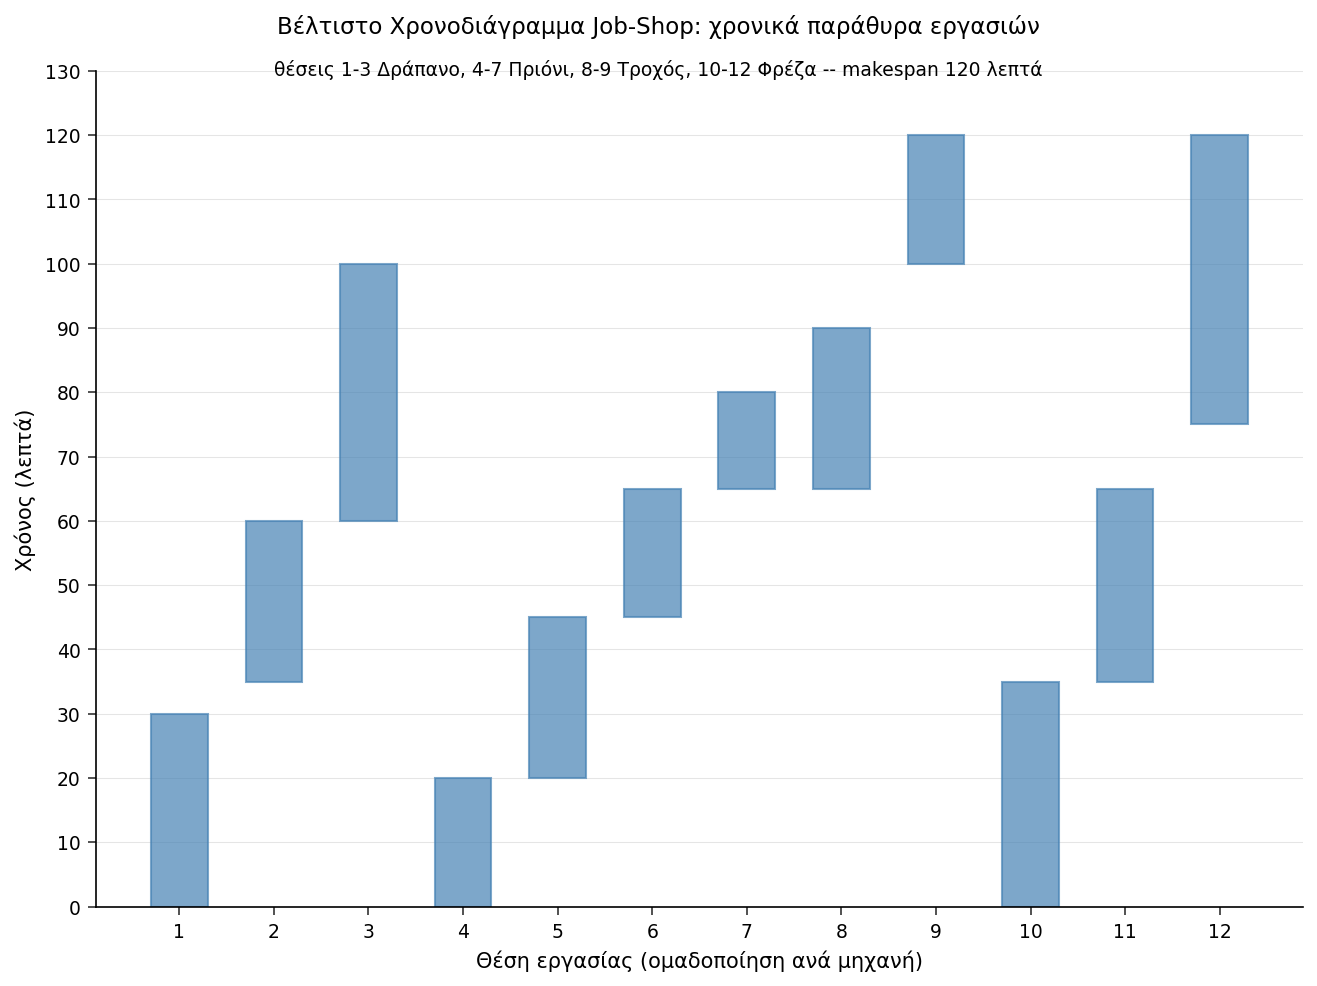

In [4]:
ΔΕΔΟΜΕΝΑ ganttdata;
    ΟΡΙΣΜΟΣ schedule;
    slot + 1;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=ganttdata noobs label;
    TITLE "Χρονοδιάγραμμα ανά θέση (η σειρά θέσεων αντιστοιχεί στο παρακάτω γράφημα)";
    ΜΕΤΑΒΛΗΤΗ slot mname jobname START FINISH;
    ΕΤΙΚΕΤΑ slot="Θέση" mname="Μηχανή" jobname="Εξάρτημα" START="Έναρξη (λεπτά)" FINISH="Λήξη (λεπτά)";
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=ganttdata noautolegend;
    TITLE "Βέλτιστο Χρονοδιάγραμμα Job-Shop: χρονικά παράθυρα εργασιών";
    title2 "θέσεις 1-3 Δράπανο, 4-7 Πριόνι, 8-9 Τροχός, 10-12 Φρέζα -- makespan 120 λεπτά";
    highlow x=slot HIGH=FINISH LOW=START / type=bar barwidth=0.65
            fillattrs=(color=steel) LINEATTRS=(color=navy);
    XAXIS ΕΤΙΚΕΤΑ="Θέση εργασίας (ομαδοποίηση ανά μηχανή)" integer
          VALUES=(1 ΕΩΣ 12 ΚΑΤΑ 1);
    YAXIS ΕΤΙΚΕΤΑ="Χρόνος (λεπτά)" grid VALUES=(0 ΕΩΣ 130 ΚΑΤΑ 10);
ΕΚΤΕΛΕΣΗ;
TITLE;

## Ερμηνεία των αποτελεσμάτων

- **Βελτιστότητα.** Ο επιλυτής MILP επέστρεψε `Solution Status = Optimal` με `Objective Value = 120`, οπότε **τα 120 λεπτά είναι το αποδεδειγμένα συντομότερο δυνατό makespan** για αυτή την περίπτωση — κανένα χρονοδιάγραμμα δεν μπορεί να τελειώσει νωρίτερα. Αυτό το πιστοποιητικό είναι που σας δίνει η διατύπωση μαθηματικού προγραμματισμού έναντι μιας καθαρής αναζήτησης εφικτότητας.

- **Το χρονοδιάγραμμα τηρεί κάθε περιορισμό.** Διαβάζοντας τον πίνακα ανά μηχανή, καμία δύο εργασίες στην ίδια μηχανή δεν επικαλύπτονται (π.χ. στο Πριόνι: Άξονας 0–20, Βραχίονας 20–45, Περίβλημα 45–65, Φλάντζα 65–80), και κάθε εξάρτημα τρέχει με τεχνολογική σειρά (π.χ. Περίβλημα: Δράπανο 0–30, μετά Πριόνι 45–65, μετά Φρέζα 75–120). Το γράφημα αιωρούμενων ράβδων δείχνει το ίδιο: εντός της ζώνης θέσεων κάθε μηχανής τα χρονικά παράθυρα παρατίθενται χωρίς σύγκρουση.

- **Τι καθορίζει το μήκος του χρονοδιαγράμματος.** Δύο εργασίες τελειώνουν ακριβώς στο λεπτό 120 — η λείανση του Βραχίονα στον Τροχό (θέση 9) και το φρεζάρισμα του Περιβλήματος στη Φρέζα (θέση 12). Και οι δύο αγγίζουν το makespan, οπότε οι μηχανές Τροχός και Φρέζα βρίσκονται στην κρίσιμη διαδρομή· η περαιτέρω μείωση του makespan θα απαιτούσε αλλαγή της ίδιας της περίπτωσης (ταχύτερες εργασίες, μια επιπλέον μηχανή ή χαλαρωμένη προτεραιότητα), όχι απλώς επανακαθορισμό της σειράς.

- **Πώς κλιμακώνεται.** Η διατύπωση αναπτύσσεται φυσικά: προσθέστε μια μηχανή ως άλλη τιμή της `machine`, προσθέστε εξαρτήματα ως περισσότερες γραμμές του `jobshop`, ή μοντελοποιήστε ημερομηνίες αποδέσμευσης και λήξης φράσσοντας το `s[o]` και προσθέτοντας περιορισμούς ημερομηνίας λήξης. Η επιτροπή σε μια μηχανή να εκτελεί πολλές εργασίες ταυτόχρονα (δυναμικότητα >1) αντικαθιστά την ανά ζεύγη διάζευξη με έναν περιορισμό αθροιστικού πόρου. Το ίδιο MILP του OPTMODEL χειρίζεται τότε πλουσιότερους κανόνες παραγωγής χωρίς αλλαγή του επιλυτή.